In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("/content/train.csv")
df_test = pd.read_csv("/content/test.csv")

In [4]:
features = ['car_age', 'km_driven', 'max_power', 'mileage', 'seats']
target = 'selling_price'

In [5]:
X_train = df_train[features].values
y_train = df_train[target].values

X_test = df_test[features].values
y_test = df_test[target].values

In [6]:
X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)
X_train_std[X_train_std == 0] = 1.0

In [7]:
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

In [8]:
k = 5
Y_pred_list = []

In [9]:
for test_row in X_test_scaled:
    distances = np.sqrt(np.sum((X_train_scaled - test_row) ** 2, axis=1))
    nearest_indices = np.argsort(distances)[:k]
    neighbor_prices = y_train[nearest_indices]
    predicted_price = np.mean(neighbor_prices)
    Y_pred_list.append(predicted_price)

Y_pred = np.array(Y_pred_list)

In [10]:
Y_pred

array([145000. , 307000. , 395199.8, ..., 206999.8, 424000. , 103035.4])

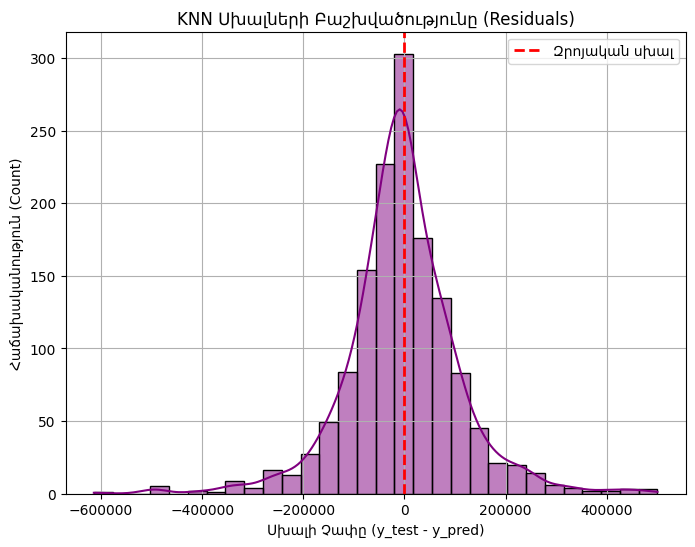

In [14]:
import seaborn as sns

residuals = y_test - Y_pred

plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True, color='purple', bins=30)

plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Զրոյական սխալ')

plt.xlabel('Սխալի Չափը (y_test - y_pred)')
plt.ylabel('Հաճախականություն (Count)')
plt.title('KNN Սխալների Բաշխվածությունը (Residuals)')
plt.legend()
plt.grid(True)
plt.show()

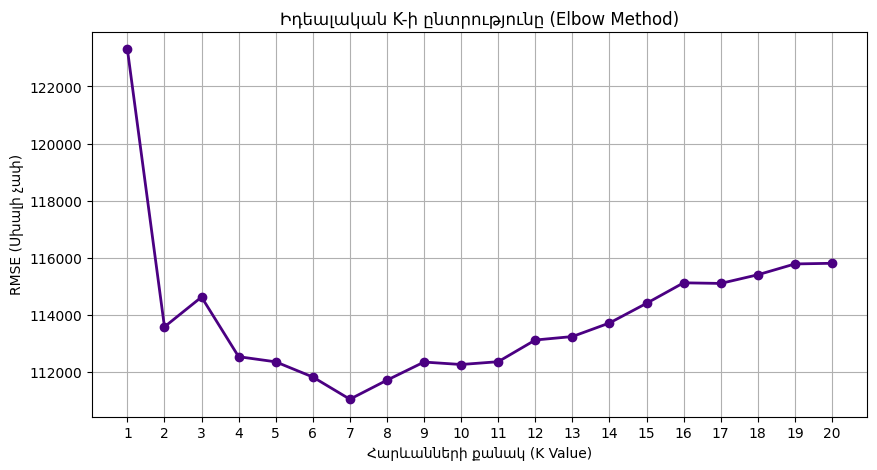

In [15]:
k_values = range(1, 21)
rmse_values = []

# Փորձարկում ենք 1-ից 20 բոլոր K-երը
for kv in k_values:
    y_pred_k = []
    for test_row in X_test_scaled:
        distances = np.sqrt(np.sum((X_train_scaled - test_row) ** 2, axis=1))
        nearest_indices = np.argsort(distances)[:kv]
        y_pred_k.append(np.mean(y_train[nearest_indices]))

    # Հաշվում ենք RMSE-ն տվյալ K-ի համար
    current_rmse = np.sqrt(np.mean((np.array(y_pred_k) - y_test) ** 2))
    rmse_values.append(current_rmse)

# Գծում ենք գրաֆիկը
plt.figure(figsize=(10, 5))
plt.plot(k_values, rmse_values, marker='o', linestyle='-', color='indigo', lw=2)
plt.xlabel('Հարևանների քանակ (K Value)')
plt.ylabel('RMSE (Սխալի չափ)')
plt.title('Իդեալական K-ի ընտրությունը (Elbow Method)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
knn_mse = np.mean((Y_pred - y_test) ** 2)
knn_rmse = np.sqrt(knn_mse)
knn_mae = np.mean(np.abs(Y_pred - y_test))

print(f"MAE: {knn_mae:.2f}")
print(f"RMSE:{knn_rmse:.2f}")

=== KNN ՄՈԴԵԼԻ ԱՐԴՅՈՒՆՔՆԵՐԸ ===
KNN MAE (Միջին սխալ): 77930.67
KNN RMSE:              112352.36

=== ՀԱՄԵՄԱՏՈՒԹՅՈՒՆ ԳԾԱՅԻՆԻ ՀԵՏ ===
Հին Գծային Ռեգրեսիայիդ թվերը սրանք էին. MAE: ~93,533 | RMSE: ~124,857
